<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/galaxy_COSMOS2015_591406.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Galaxy COSMOS2015 591406**

[The COSMOS2015 Catalog: Exploring the 1 < z < 6 Universe with half a million galaxies](https://arxiv.org/abs/1604.02350): contains precise photometric redshifts and stellar masses for more than half a million objects over the 2deg$^2$ COSMOS field.

The [COSMOS2015 catalogue (Caltech)](https://cosmos.astro.caltech.edu/page/photom) contains precise PSF-matched photometry, photometric redshifts and stellar masses for more than half a million of sources (excluding masked area) on the COSMOS field.

In [ ]:
!pip install astropy astroquery -q
from astroquery.ipac.irsa import Irsa
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astropy import coordinates
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Decimal degrees format for object COSMOS2015 591406
ra_deg = '150.01d'
dec_deg = '2.2d'

In [3]:
# Convert to traditional dms
coord = SkyCoord(ra=ra_deg, dec=dec_deg, frame='icrs')
ra_hms = coord.ra.to_string(unit='hour', sep=' ', precision=3, pad=True)
dec_dms = coord.dec.to_string(unit='deg', sep=' ', precision=2, alwayssign=True, pad=True)

print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

RA (h:m:s): 10 00 02.400
DEC (d:m:s): +02 12 00.00


In [4]:
# Reverse check to see to which object the coordinates belong
coord = SkyCoord(ra=ra_deg, dec=dec_deg, frame='icrs')
result = Simbad.query_region(coord, radius='0d0m5s')  # Search within a small radius (5 arcseconds)
if result:
    print(result['MAIN_ID'][0])  # Show the main name of the object
else:
    print("No object found in SIMBAD at these coordinates.")
object_name = 'MAIN_ID'

COSMOS2015 591406


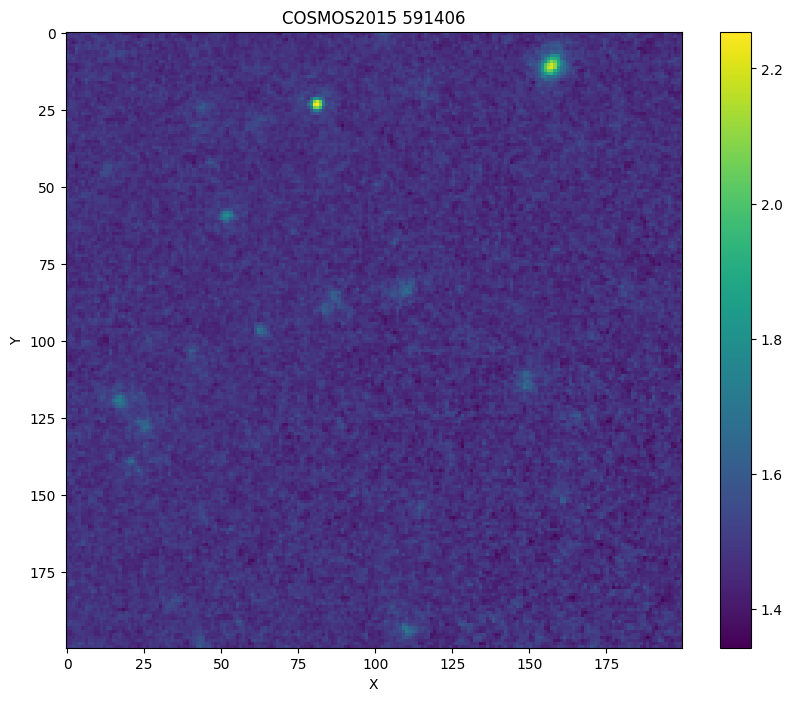

In [6]:
# Simple image access queries¶
coord = SkyCoord('150.01d 2.2d', frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Open a cutout image for one of the science images
science_image = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'][0]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8))
plt.imshow(cutout.data, cmap='viridis')
plt.colorbar()
plt.title(object_name)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

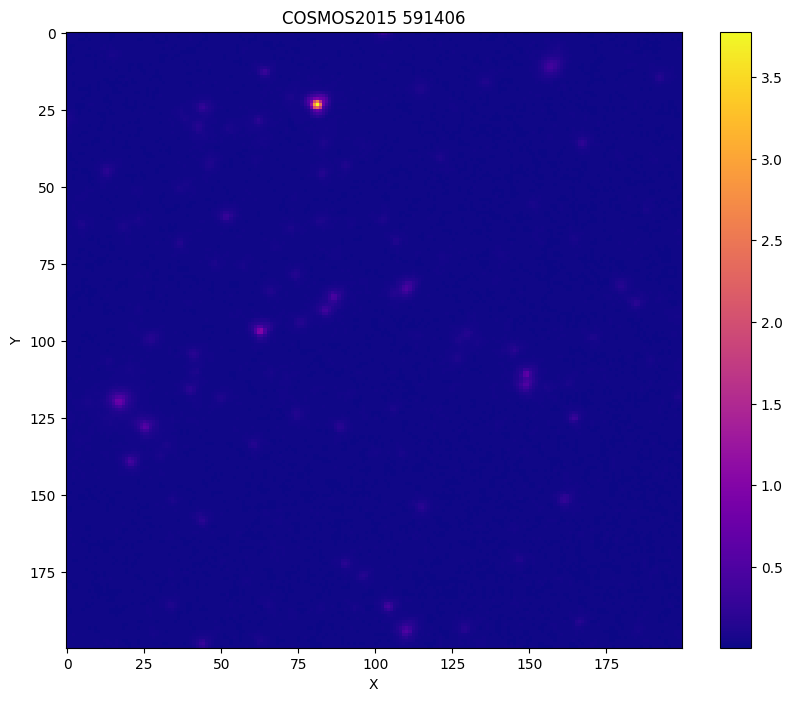

In [13]:
# Simple image access queries¶
coord = SkyCoord('150.01d 2.2d', frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Open a cutout image for one of the science images
science_image = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'][1]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8))
plt.imshow(cutout.data, cmap='plasma')
plt.colorbar()
plt.title(object_name)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

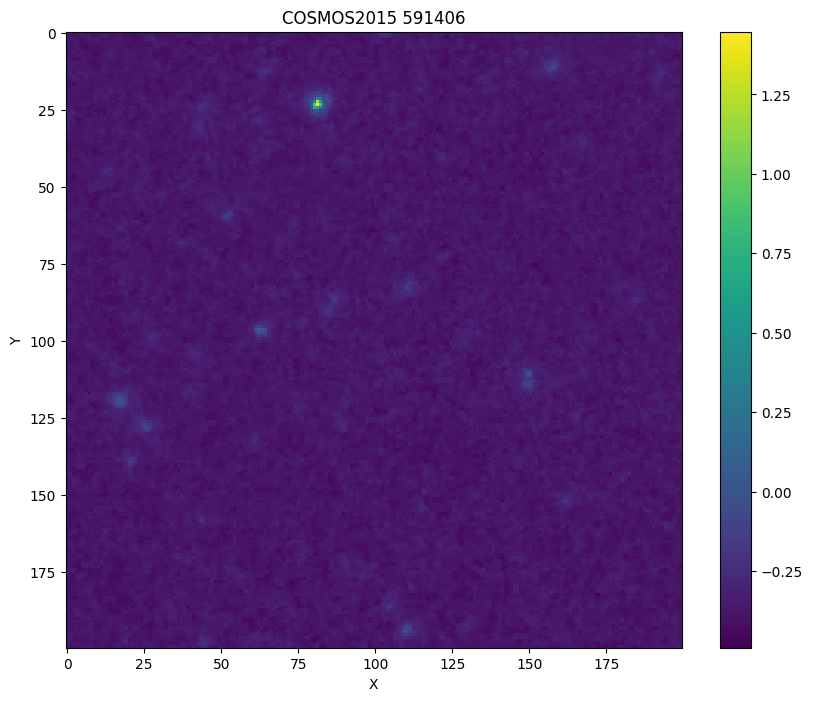

In [12]:
# Simple image access queries¶
coord = SkyCoord('150.01d 2.2d', frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Open a cutout image for one of the science images
science_image = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'][3]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8))
plt.imshow(cutout.data, cmap='viridis')
plt.colorbar()
plt.title(object_name)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

*Get more details about the astronomical data file*

In [7]:
hdul.info()

Filename: <class 'fsspec.implementations.http.HTTPFile'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      77   (4554, 4551)   float32   


In [9]:
hdul = fits.open(science_image['access_url'], use_fsspec=True)

In [10]:
#  Access the primary HDU (Header/Data Unit) to get the data
primary_hdu = hdul[0]
data = primary_hdu.data
print(primary_hdu.header) # Display the header to learn more about the file
print(repr(hdul[0].header))  # Science data HDU header

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel - floating point                NAXIS   =                    2 / Number of axes                                 NAXIS1  =                 4554 / X axis length                                  NAXIS2  =                 4551 / Y axis length                                  ORIGIN  = 'Spitzer Super-Mosaic Pipeline' / Origin of these image data          CREATOR = 'Spitzer Science Center' / Creator of this FITS file                                                                                                            / TIME AND EXPOSURE INFORMATION                                                                                                                       TELESCOP= 'Spitzer '           / Name of Telescope                              INSTRUME= 'IRAC    '           / Name of Instrument                             CHNLNUM =                    4 / Instrum

In [ ]:
# Close the FITS file
hdul.close()